# Propulsion Power Prediction - Model Inference

This notebook loads trained models from checkpoints and generates predictions on real data.

## Contents
1. Setup & Configuration
2. Load Real Data
3. Feature Engineering & Preprocessing
4. Load Trained Models
5. Generate Predictions
6. Evaluate & Compare Models
7. Visualizations
8. Export Results
9. Summary

## 1. Setup & Configuration

In [2]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import joblib
import warnings
warnings.filterwarnings('ignore')

# Add models directory to path
sys.path.insert(0, 'models')

# Import our modules
from config import Config, default_config
from data_module import DataScaler, TargetScaler, FeatureEngineer
from neural_models import MLP, GaussianMLP, NeuralNetworkTrainer, create_mlp
from uncertainty import DeepEnsemble

# PyTorch
import torch

# Plot settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.style.use('seaborn-v0_8-whitegrid')

# Paths
CHECKPOINT_DIR = './checkpoints' # You can train models and save checkpoints yourself or get pre-trained models from a teammate.
DATA_DIR = './data/real_data'
OUTPUT_DIR = './outputs/predictions'

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")
print(f"\nCheckpoint directory: {CHECKPOINT_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")


PyTorch version: 2.6.0+cu124
Device: CUDA

Checkpoint directory: ./checkpoints
Data directory: ./data/real_data
Output directory: ./outputs/predictions


In [3]:
# List available checkpoints
print("Available checkpoints:")
for item in os.listdir(CHECKPOINT_DIR):
    path = os.path.join(CHECKPOINT_DIR, item)
    if os.path.isdir(path):
        print(f"  [DIR] {item}/")
        for subitem in os.listdir(path):
            print(f"         - {subitem}")
    else:
        print(f"  {item}")


Available checkpoints:
  [DIR] ensemble/
         - member_0.pt
         - member_1.pt
         - member_2.pt
         - member_3.pt
         - member_4.pt
         - metadata.npy
  feature_scaler.joblib
  mlp_model.pt
  rf_model.joblib
  target_scaler.joblib
  [DIR] v1.0/
         - ensemble
         - feature_scaler.joblib
         - mlp_model.pt
         - README.md
         - rf_model.joblib
         - target_scaler.joblib
         - xgb_model.joblib
  xgb_model.joblib


## 2. Load Real Data

In [4]:
# Configuration
config = default_config
INDEX_COLUMN = 'time_id'
TARGET_COLUMN = 'power'

# Load datasets
print("Loading real data...")

train_df = pd.read_csv(os.path.join(DATA_DIR, 'train.csv'))
dev_in_df = pd.read_csv(os.path.join(DATA_DIR, 'dev_in.csv'))
dev_out_df = pd.read_csv(os.path.join(DATA_DIR, 'dev_out.csv'))

# Set index
train_df.set_index(INDEX_COLUMN, inplace=True, drop=True)
dev_in_df.set_index(INDEX_COLUMN, inplace=True, drop=True)
dev_out_df.set_index(INDEX_COLUMN, inplace=True, drop=True)

print(f"\nDataset sizes:")
print(f"  Train: {len(train_df):,} samples")
print(f"  Dev-in (in-distribution): {len(dev_in_df):,} samples")
print(f"  Dev-out (out-of-distribution): {len(dev_out_df):,} samples")


Loading real data...

Dataset sizes:
  Train: 530,706 samples
  Dev-in (in-distribution): 18,368 samples
  Dev-out (out-of-distribution): 18,368 samples


In [5]:
# Preview data
print("Sample data (dev_in):")
dev_in_df.head()


Sample data (dev_in):


,draft_aft_telegram,draft_fore_telegram,stw,diff_speed_overground,awind_vcomp_provider,awind_ucomp_provider,rcurrent_vcomp,rcurrent_ucomp,comb_wind_swell_wave_height,timeSinceDryDock,power
time_id,,,,,,,,,,,
1306151,12.60,12.52,18.260300,0.0,20.479392,7.799338,0.001016,0.112642,1.64044,1316927.0,21364.0
1468659,12.99,13.50,19.020000,0.0,16.110422,2.765609,0.003940,0.331406,1.71667,1479435.0,24025.0
819248,13.85,13.85,15.740300,0.0,19.308928,3.022072,0.088337,0.093082,4.60139,830024.0,17687.0
1325937,10.60,10.40,14.471200,0.0,14.109561,3.312518,-0.023950,0.867955,1.17817,1336713.0,10411.0
1540530,13.20,13.20,20.243601,-0.1,26.392602,0.404267,-0.312690,-0.052353,1.22900,1551306.0,28771.0


In [6]:
# Data statistics
print("Data statistics (dev_in):")
dev_in_df.describe().T


Data statistics (dev_in):


,count,mean,std,min,25%,50%,75%,max
draft_aft_telegram,18368.0,12.250512,1.509341,7.650000,11.100000,1.257000e+01,1.340000e+01,1.470000e+01
draft_fore_telegram,18368.0,11.989969,1.732759,5.900000,10.900000,1.240000e+01,1.335000e+01,1.470000e+01
stw,18368.0,17.282093,2.923841,5.091200,15.140350,1.838360e+01,1.925620e+01,2.367000e+01
diff_speed_overground,18368.0,0.001570,0.176026,-2.000000,-0.060000,0.000000e+00,1.000000e-01,2.000000e+00
awind_vcomp_provider,18368.0,16.440132,8.896309,-12.576989,9.751648,1.623922e+01,2.306151e+01,4.006345e+01
awind_ucomp_provider,18368.0,6.005511,4.525707,0.000377,2.341411,4.918073e+00,8.821153e+00,1.898892e+01
rcurrent_vcomp,18368.0,0.006201,0.465172,-1.978244,-0.184735,1.253903e-02,1.964565e-01,1.981395e+00
rcurrent_ucomp,18368.0,-0.002299,0.345423,-1.971816,-0.150961,-6.613612e-03,1.469950e-01,1.927844e+00
comb_wind_swell_wave_height,18368.0,1.561122,0.868165,0.000221,0.964205,1.463815e+00,2.041030e+00,5.332810e+00
timeSinceDryDock,18368.0,972619.889209,458253.540614,10802.000000,646331.250000,1.035393e+06,1.361544e+06,1.735509e+06


## 3. Feature Engineering & Preprocessing

In [7]:
# Apply feature engineering
feature_engineer = FeatureEngineer()

print("Applying feature engineering...")
train_df = feature_engineer.fit_transform(train_df)
dev_in_df = feature_engineer.transform(dev_in_df)
dev_out_df = feature_engineer.transform(dev_out_df)

print(f"Features after engineering: {len(train_df.columns)} columns")
print(f"Columns: {list(train_df.columns)}")


Applying feature engineering...
Features after engineering: 20 columns
Columns: ['draft_aft_telegram', 'draft_fore_telegram', 'stw', 'diff_speed_overground', 'awind_vcomp_provider', 'awind_ucomp_provider', 'rcurrent_vcomp', 'rcurrent_ucomp', 'comb_wind_swell_wave_height', 'timeSinceDryDock', 'power', 'stw_cubed', 'stw_squared', 'mean_draft', 'trim', 'wind_magnitude', 'wind_angle', 'current_magnitude', 'current_angle', 'speed_wind_interaction']


In [8]:
# Load fitted scalers from checkpoints
print("Loading scalers from checkpoints...")

feature_scaler = DataScaler.load(os.path.join(CHECKPOINT_DIR, 'feature_scaler.joblib'))
target_scaler = TargetScaler.load(os.path.join(CHECKPOINT_DIR, 'target_scaler.joblib'))

print(f"Feature scaler loaded - {len(feature_scaler.feature_names)} features")
print(f"Target scaler loaded - mean: {target_scaler.mean:.2f}, std: {target_scaler.std:.2f}")


Loading scalers from checkpoints...
Feature scaler loaded - 19 features
Target scaler loaded - mean: 19153.33, std: 8205.56


In [9]:
# Get feature columns (must match what was used during training)
feature_columns = feature_scaler.feature_names

print(f"Using {len(feature_columns)} features:")
for i, col in enumerate(feature_columns, 1):
    print(f"  {i:2d}. {col}")


Using 19 features:
   1. draft_aft_telegram
   2. draft_fore_telegram
   3. stw
   4. diff_speed_overground
   5. awind_vcomp_provider
   6. awind_ucomp_provider
   7. rcurrent_vcomp
   8. rcurrent_ucomp
   9. comb_wind_swell_wave_height
  10. timeSinceDryDock
  11. stw_cubed
  12. stw_squared
  13. mean_draft
  14. trim
  15. wind_magnitude
  16. wind_angle
  17. current_magnitude
  18. current_angle
  19. speed_wind_interaction


In [10]:
# Prepare scaled data for predictions
print("Scaling features...")

# Scale features
X_train = feature_scaler.transform(train_df[feature_columns])
X_dev_in = feature_scaler.transform(dev_in_df[feature_columns])
X_dev_out = feature_scaler.transform(dev_out_df[feature_columns])

# Get true targets (unscaled for evaluation)
y_train = train_df[TARGET_COLUMN].values
y_dev_in = dev_in_df[TARGET_COLUMN].values
y_dev_out = dev_out_df[TARGET_COLUMN].values

# Also get scaled targets for internal model predictions
y_train_scaled = target_scaler.transform(y_train)
y_dev_in_scaled = target_scaler.transform(y_dev_in)
y_dev_out_scaled = target_scaler.transform(y_dev_out)

print(f"\nScaled data shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_dev_in: {X_dev_in.shape}")
print(f"  X_dev_out: {X_dev_out.shape}")


Scaling features...

Scaled data shapes:
  X_train: (530706, 19)
  X_dev_in: (18368, 19)
  X_dev_out: (18368, 19)


## 4. Load Trained Models

In [11]:
# Device for neural networks
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


### 4.1 Load Random Forest Model

In [12]:
# Load Random Forest
rf_path = os.path.join(CHECKPOINT_DIR, 'rf_model.joblib')
rf_model = joblib.load(rf_path)
print(f"Random Forest loaded from {rf_path}")
print(f"  Number of estimators: {rf_model.model.n_estimators}")


Random Forest loaded from ./checkpoints\rf_model.joblib
  Number of estimators: 200


### 4.2 Load XGBoost Model


In [13]:
# Load XGBoost
xgb_path = os.path.join(CHECKPOINT_DIR, 'xgb_model.joblib')
xgb_model = joblib.load(xgb_path)
print(f"XGBoost loaded from {xgb_path}")


XGBoost loaded from ./checkpoints\xgb_model.joblib


### 4.3 Load MLP Model


In [14]:
# Load MLP
mlp_path = os.path.join(CHECKPOINT_DIR, 'mlp_model.pt')

# Create model with same architecture
input_dim = X_train.shape[1]
mlp_model = create_mlp(input_dim=input_dim, config=config.model, gaussian_output=False)
mlp_model.to(device)

# Load weights
checkpoint = torch.load(mlp_path, map_location=device, weights_only=False)
mlp_model.load_state_dict(checkpoint['model_state_dict'])
mlp_model.eval()

print(f"MLP loaded from {mlp_path}")
print(f"  Architecture: {config.model.hidden_layers}")
print(f"  Best validation loss: {checkpoint.get('best_val_loss', 'N/A')}")


MLP loaded from ./checkpoints\mlp_model.pt
  Architecture: [128, 64, 32]
  Best validation loss: 0.03158689260133553


### 4.4 Load Deep Ensemble


In [15]:
# Load ensemble metadata
ensemble_dir = os.path.join(CHECKPOINT_DIR, 'ensemble')
metadata_path = os.path.join(ensemble_dir, 'metadata.npy')
metadata = np.load(metadata_path, allow_pickle=True).item()

print(f"Ensemble metadata:")
print(f"  Number of members: {metadata['n_members']}")
print(f"  Input dimension: {metadata['input_dim']}")
print(f"  Gaussian output: {metadata['gaussian_output']}")


Ensemble metadata:
  Number of members: 5
  Input dimension: 19
  Gaussian output: False


In [16]:
# Load ensemble members
n_members = metadata['n_members']
ensemble_models = []
ensemble_trainers = []

for i in range(n_members):
    member_path = os.path.join(ensemble_dir, f'member_{i}.pt')
    
    # Create model
    model = create_mlp(
        input_dim=metadata['input_dim'],
        config=config.model,
        gaussian_output=metadata['gaussian_output']
    )
    model.to(device)
    
    # Create trainer wrapper
    trainer = NeuralNetworkTrainer(
        model=model,
        learning_rate=config.model.learning_rate,
        batch_size=config.model.batch_size,
        max_epochs=config.model.max_epochs
    )
    
    # Load checkpoint
    checkpoint = torch.load(member_path, map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()
    
    ensemble_models.append(model)
    ensemble_trainers.append(trainer)
    print(f"  Loaded member {i} from {member_path}")

print(f"\nDeep Ensemble loaded with {n_members} members")


  Loaded member 0 from ./checkpoints\ensemble\member_0.pt
  Loaded member 1 from ./checkpoints\ensemble\member_1.pt
  Loaded member 2 from ./checkpoints\ensemble\member_2.pt
  Loaded member 3 from ./checkpoints\ensemble\member_3.pt
  Loaded member 4 from ./checkpoints\ensemble\member_4.pt

Deep Ensemble loaded with 5 members


## 5. Generate Predictions

In [17]:
def predict_rf(X):
    """Generate predictions using Random Forest (scaled predictions, need inverse transform)."""
    pred_scaled = rf_model.predict(X)
    return target_scaler.inverse_transform(pred_scaled)

def predict_xgb(X):
    """Generate predictions using XGBoost (scaled predictions, need inverse transform)."""
    pred_scaled = xgb_model.predict(X)
    return target_scaler.inverse_transform(pred_scaled)

def predict_mlp(X):
    """Generate predictions using MLP (scaled predictions, need inverse transform)."""
    X_tensor = torch.FloatTensor(X).to(device)
    with torch.no_grad():
        pred_scaled = mlp_model(X_tensor).cpu().numpy()
    return target_scaler.inverse_transform(pred_scaled)

def predict_ensemble(X):
    """Generate predictions using Deep Ensemble with uncertainty."""
    X_tensor = torch.FloatTensor(X).to(device)
    
    all_preds = []
    for model in ensemble_models:
        model.eval()
        with torch.no_grad():
            if isinstance(model, GaussianMLP):
                pred, _ = model(X_tensor)
            else:
                pred = model(X_tensor)
            all_preds.append(pred.cpu().numpy())
    
    all_preds = np.array(all_preds)
    
    # Mean prediction
    mean_pred_scaled = np.mean(all_preds, axis=0)
    mean_pred = target_scaler.inverse_transform(mean_pred_scaled)
    
    # Epistemic uncertainty (std across ensemble members)
    std_scaled = np.std(all_preds, axis=0)
    uncertainty = std_scaled * target_scaler.std  # Scale uncertainty to original units
    
    return mean_pred, uncertainty


In [18]:
# Generate predictions for all datasets
print("Generating predictions...")

# Store predictions in dictionaries
predictions = {
    'dev_in': {},
    'dev_out': {}
}

# Dev-in predictions
print("\nDev-in predictions:")
predictions['dev_in']['rf'] = predict_rf(X_dev_in)
print("  Random Forest: done")
predictions['dev_in']['xgb'] = predict_xgb(X_dev_in)
print("  XGBoost: done")
predictions['dev_in']['mlp'] = predict_mlp(X_dev_in)
print("  MLP: done")
predictions['dev_in']['ensemble_mean'], predictions['dev_in']['ensemble_std'] = predict_ensemble(X_dev_in)
print("  Deep Ensemble: done")

# Dev-out predictions
print("\nDev-out predictions:")
predictions['dev_out']['rf'] = predict_rf(X_dev_out)
print("  Random Forest: done")
predictions['dev_out']['xgb'] = predict_xgb(X_dev_out)
print("  XGBoost: done")
predictions['dev_out']['mlp'] = predict_mlp(X_dev_out)
print("  MLP: done")
predictions['dev_out']['ensemble_mean'], predictions['dev_out']['ensemble_std'] = predict_ensemble(X_dev_out)
print("  Deep Ensemble: done")

print("\n✓ All predictions generated!")


Generating predictions...

Dev-in predictions:
  Random Forest: done
  XGBoost: done
  MLP: done
  Deep Ensemble: done

Dev-out predictions:
  Random Forest: done
  XGBoost: done
  MLP: done
  Deep Ensemble: done

✓ All predictions generated!


## 6. Evaluate & Compare Models

In [19]:
def compute_metrics(y_true, y_pred):
    """Compute regression metrics."""
    errors = y_true - y_pred
    abs_errors = np.abs(errors)
    
    mae = np.mean(abs_errors)
    rmse = np.sqrt(np.mean(errors**2))
    mape = np.mean(abs_errors / np.abs(y_true + 1e-8)) * 100
    
    # R-squared
    ss_res = np.sum(errors**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    r2 = 1 - (ss_res / ss_tot)
    
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': mape,
        'R²': r2
    }


In [20]:
# Compute metrics for all models on dev-in
print("=" * 60)
print("DEV-IN (In-Distribution) Performance")
print("=" * 60)

models = ['rf', 'xgb', 'mlp', 'ensemble_mean']
model_names = ['Random Forest', 'XGBoost', 'MLP', 'Deep Ensemble']

results_dev_in = []
for model_key, model_name in zip(models, model_names):
    metrics = compute_metrics(y_dev_in, predictions['dev_in'][model_key])
    metrics['Model'] = model_name
    results_dev_in.append(metrics)

df_results_in = pd.DataFrame(results_dev_in)
df_results_in = df_results_in[['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']]
df_results_in


DEV-IN (In-Distribution) Performance


,Model,MAE,RMSE,MAPE (%),R²
0,Random Forest,267.430794,594.852471,1.860559,0.995165
1,XGBoost,673.748998,1027.136613,4.419969,0.985583
2,MLP,998.079548,1478.541806,5.959478,0.970126
3,Deep Ensemble,881.033652,1328.744651,5.548698,0.975873


In [21]:
# Compute metrics for all models on dev-out
print("=" * 60)
print("DEV-OUT (Out-of-Distribution) Performance")
print("=" * 60)

results_dev_out = []
for model_key, model_name in zip(models, model_names):
    metrics = compute_metrics(y_dev_out, predictions['dev_out'][model_key])
    metrics['Model'] = model_name
    results_dev_out.append(metrics)

df_results_out = pd.DataFrame(results_dev_out)
df_results_out = df_results_out[['Model', 'MAE', 'RMSE', 'MAPE (%)', 'R²']]
df_results_out


DEV-OUT (Out-of-Distribution) Performance


,Model,MAE,RMSE,MAPE (%),R²
0,Random Forest,2232.261581,3193.801289,14.154165,0.756708
1,XGBoost,1405.397426,2061.726672,9.002177,0.898615
2,MLP,1667.269730,2479.113662,9.814764,0.853410
3,Deep Ensemble,1671.035131,2503.737703,9.659695,0.850483


In [22]:
# Compare performance degradation from dev-in to dev-out
print("\n" + "=" * 60)
print("Performance Degradation (Dev-Out vs Dev-In)")
print("=" * 60)

degradation = []
for i, model_name in enumerate(model_names):
    in_mae = df_results_in.iloc[i]['MAE']
    out_mae = df_results_out.iloc[i]['MAE']
    in_rmse = df_results_in.iloc[i]['RMSE']
    out_rmse = df_results_out.iloc[i]['RMSE']
    
    degradation.append({
        'Model': model_name,
        'MAE Dev-In': in_mae,
        'MAE Dev-Out': out_mae,
        'MAE Δ%': ((out_mae - in_mae) / in_mae) * 100,
        'RMSE Dev-In': in_rmse,
        'RMSE Dev-Out': out_rmse,
        'RMSE Δ%': ((out_rmse - in_rmse) / in_rmse) * 100
    })

df_degradation = pd.DataFrame(degradation)
df_degradation



Performance Degradation (Dev-Out vs Dev-In)


,Model,MAE Dev-In,MAE Dev-Out,MAE Δ%,RMSE Dev-In,RMSE Dev-Out,RMSE Δ%
0,Random Forest,267.430794,2232.261581,734.706261,594.852471,3193.801289,436.906451
1,XGBoost,673.748998,1405.397426,108.593620,1027.136613,2061.726672,100.725653
2,MLP,998.079548,1667.269730,67.047780,1478.541806,2479.113662,67.672882
3,Deep Ensemble,881.033652,1671.035131,89.667571,1328.744651,2503.737703,88.428808


## 7. Visualizations

In [23]:
# Color palette
colors = {
    'rf': '#2ecc71',
    'xgb': '#3498db',
    'mlp': '#e74c3c',
    'ensemble': '#9b59b6'
}


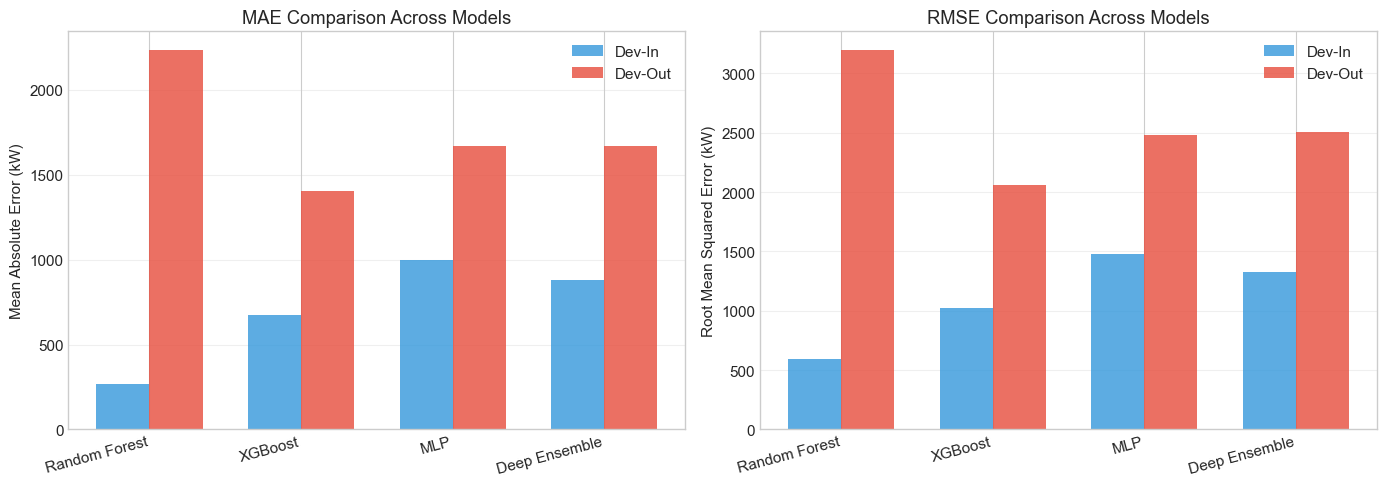

In [24]:
# Bar chart comparing MAE across models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(model_names))
width = 0.35

# MAE comparison
ax = axes[0]
bars1 = ax.bar(x - width/2, df_results_in['MAE'], width, label='Dev-In', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, df_results_out['MAE'], width, label='Dev-Out', color='#e74c3c', alpha=0.8)
ax.set_ylabel('Mean Absolute Error (kW)')
ax.set_title('MAE Comparison Across Models')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# RMSE comparison
ax = axes[1]
bars1 = ax.bar(x - width/2, df_results_in['RMSE'], width, label='Dev-In', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, df_results_out['RMSE'], width, label='Dev-Out', color='#e74c3c', alpha=0.8)
ax.set_ylabel('Root Mean Squared Error (kW)')
ax.set_title('RMSE Comparison Across Models')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


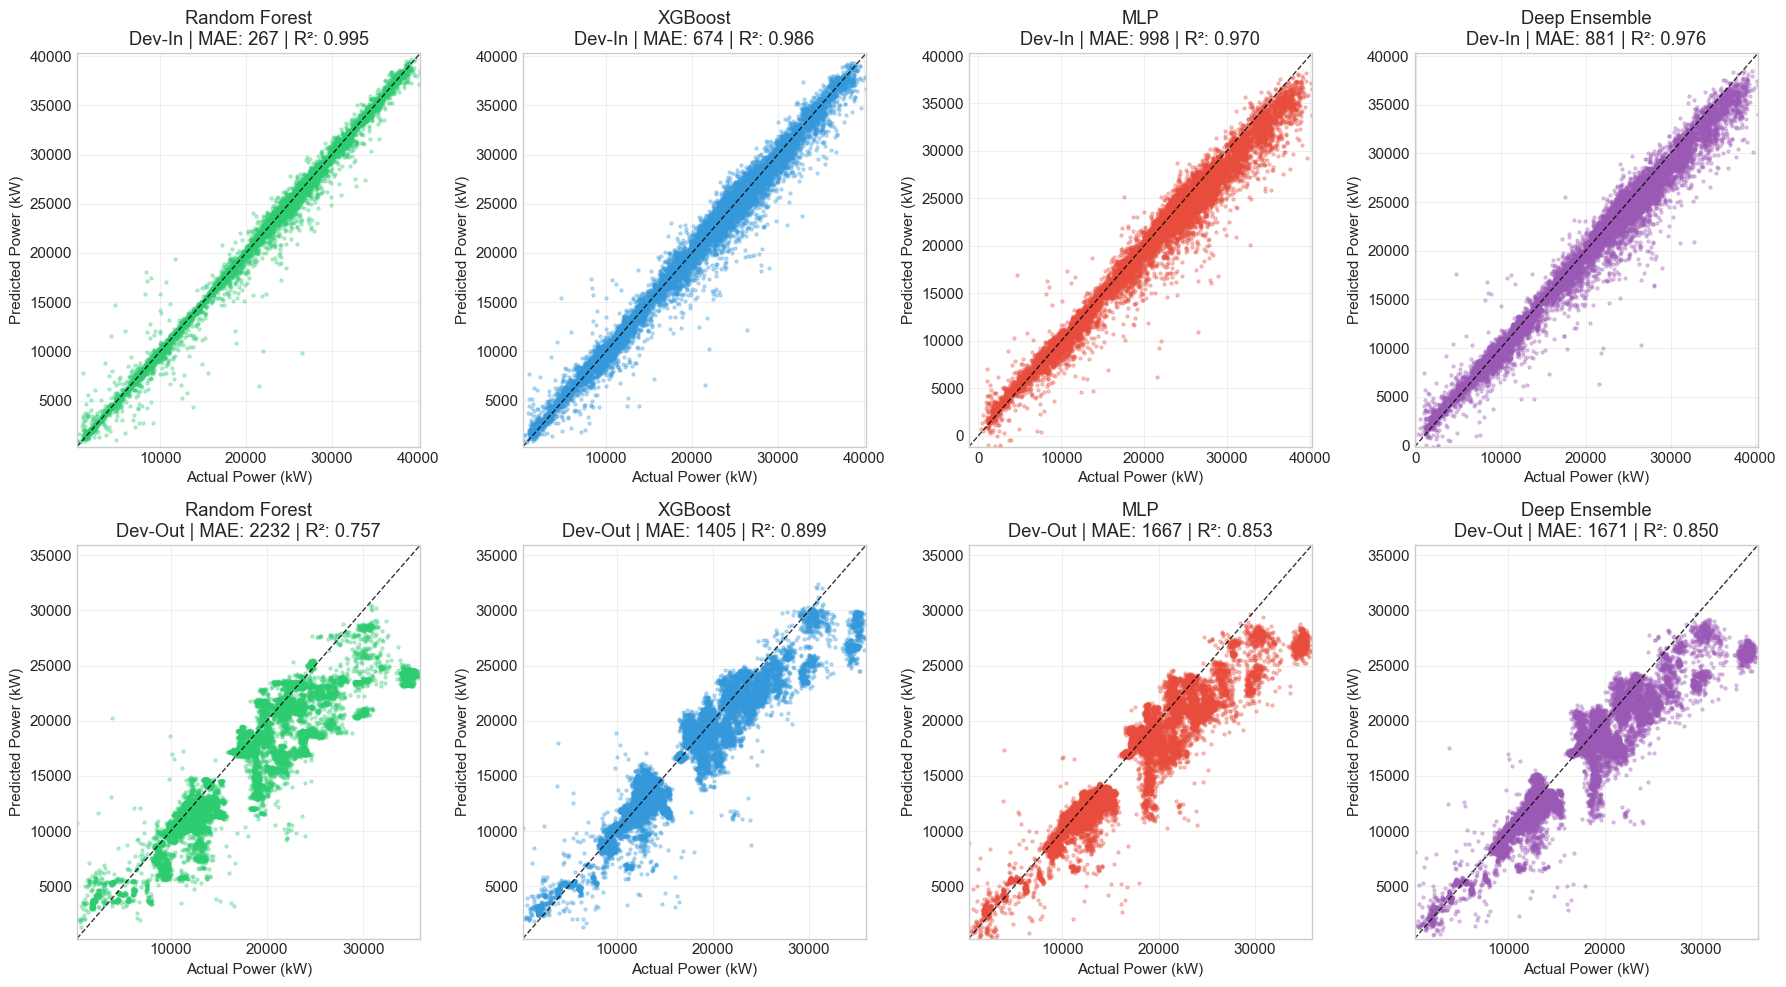

In [25]:
# Scatter plots: Predicted vs Actual
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

datasets = [('dev_in', y_dev_in, 'Dev-In'), ('dev_out', y_dev_out, 'Dev-Out')]
model_keys = ['rf', 'xgb', 'mlp', 'ensemble_mean']

for row, (data_key, y_true, data_name) in enumerate(datasets):
    for col, (model_key, model_name) in enumerate(zip(model_keys, model_names)):
        ax = axes[row, col]
        y_pred = predictions[data_key][model_key]
        
        # Scatter plot
        ax.scatter(y_true, y_pred, alpha=0.3, s=5, c=list(colors.values())[col])
        
        # Perfect prediction line
        lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
        ax.plot(lims, lims, 'k--', alpha=0.8, linewidth=1, label='Perfect')
        
        # Metrics
        mae = np.mean(np.abs(y_true - y_pred))
        r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
        
        ax.set_xlabel('Actual Power (kW)')
        ax.set_ylabel('Predicted Power (kW)')
        ax.set_title(f'{model_name}\n{data_name} | MAE: {mae:.0f} | R²: {r2:.3f}')
        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'predictions_scatter.png'), dpi=150, bbox_inches='tight')
plt.show()


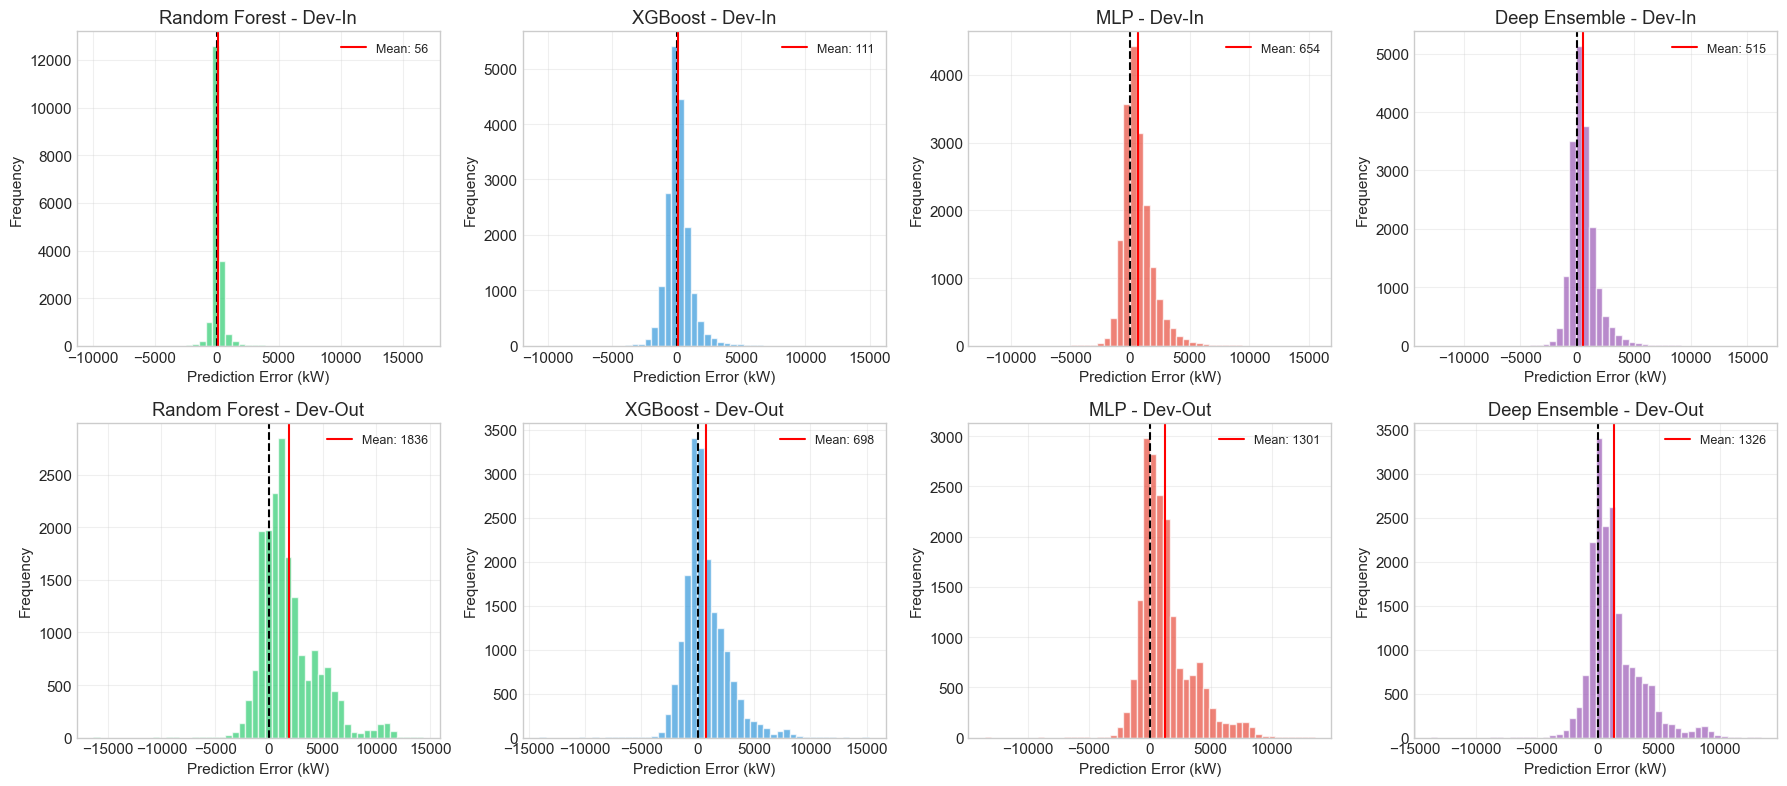

In [26]:
# Error distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for row, (data_key, y_true, data_name) in enumerate(datasets):
    for col, (model_key, model_name) in enumerate(zip(model_keys, model_names)):
        ax = axes[row, col]
        y_pred = predictions[data_key][model_key]
        errors = y_true - y_pred
        
        ax.hist(errors, bins=50, alpha=0.7, color=list(colors.values())[col], edgecolor='white')
        ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5)
        ax.axvline(x=np.mean(errors), color='red', linestyle='-', linewidth=1.5, label=f'Mean: {np.mean(errors):.0f}')
        
        ax.set_xlabel('Prediction Error (kW)')
        ax.set_ylabel('Frequency')
        ax.set_title(f'{model_name} - {data_name}')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'error_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()


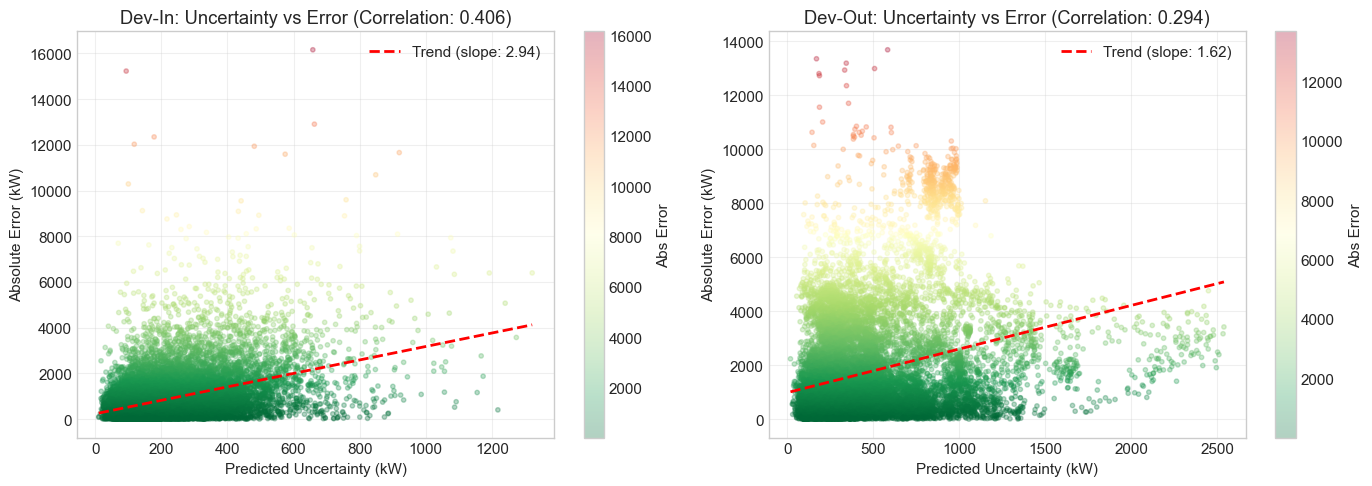

In [27]:
# Ensemble uncertainty analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (data_key, y_true, data_name) in zip(axes, datasets):
    y_pred = predictions[data_key]['ensemble_mean']
    uncertainty = predictions[data_key]['ensemble_std']
    abs_error = np.abs(y_true - y_pred)
    
    # Scatter: uncertainty vs error
    scatter = ax.scatter(uncertainty, abs_error, alpha=0.3, s=10, c=abs_error, cmap='RdYlGn_r')
    
    # Trend line
    z = np.polyfit(uncertainty, abs_error, 1)
    p = np.poly1d(z)
    x_line = np.linspace(uncertainty.min(), uncertainty.max(), 100)
    ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend (slope: {z[0]:.2f})')
    
    # Correlation
    corr = np.corrcoef(uncertainty, abs_error)[0, 1]
    
    ax.set_xlabel('Predicted Uncertainty (kW)')
    ax.set_ylabel('Absolute Error (kW)')
    ax.set_title(f'{data_name}: Uncertainty vs Error (Correlation: {corr:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.colorbar(scatter, ax=ax, label='Abs Error')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'uncertainty_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()


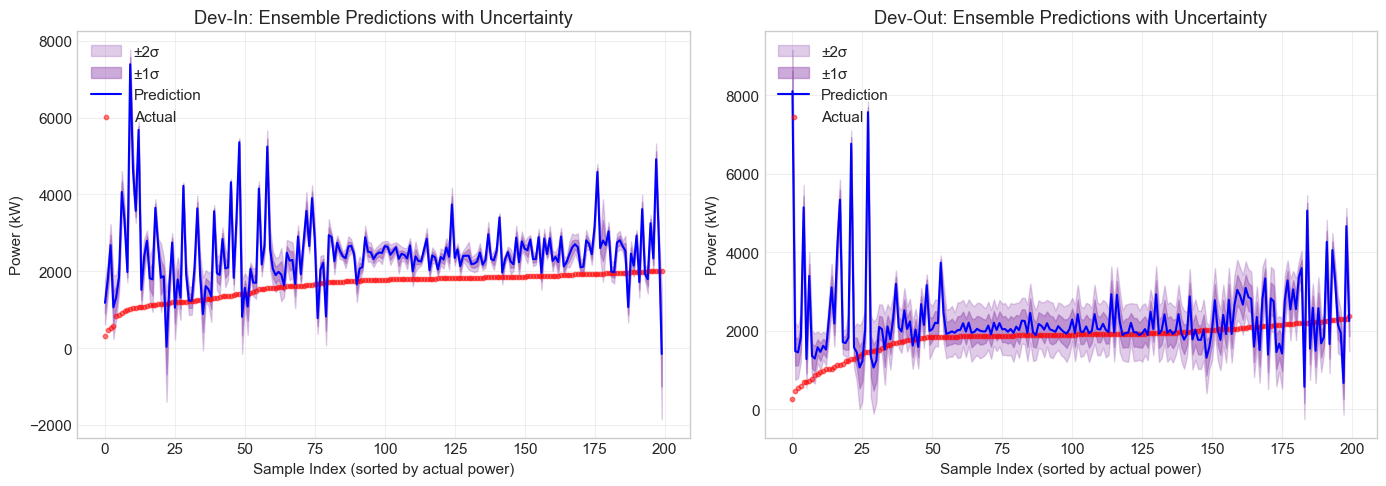

In [28]:
# Sample predictions with uncertainty bands (ensemble)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

n_samples = 200  # Number of samples to visualize

for ax, (data_key, y_true, data_name) in zip(axes, datasets):
    # Sort by actual value for better visualization
    idx = np.argsort(y_true)[:n_samples]
    
    y_actual = y_true[idx]
    y_pred = predictions[data_key]['ensemble_mean'][idx]
    uncertainty = predictions[data_key]['ensemble_std'][idx]
    
    x = np.arange(len(idx))
    
    ax.fill_between(x, y_pred - 2*uncertainty, y_pred + 2*uncertainty, 
                     alpha=0.3, color='#9b59b6', label='±2σ')
    ax.fill_between(x, y_pred - uncertainty, y_pred + uncertainty, 
                     alpha=0.5, color='#9b59b6', label='±1σ')
    ax.plot(x, y_pred, 'b-', linewidth=1.5, label='Prediction')
    ax.scatter(x, y_actual, c='red', s=10, alpha=0.5, label='Actual')
    
    ax.set_xlabel('Sample Index (sorted by actual power)')
    ax.set_ylabel('Power (kW)')
    ax.set_title(f'{data_name}: Ensemble Predictions with Uncertainty')
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'predictions_with_uncertainty.png'), dpi=150, bbox_inches='tight')
plt.show()


## 8. Export Results

In [29]:
# Create results DataFrames
def create_results_df(data_key, df, y_true):
    """Create a DataFrame with all predictions."""
    results = df.copy()
    results['actual_power'] = y_true
    results['pred_rf'] = predictions[data_key]['rf']
    results['pred_xgb'] = predictions[data_key]['xgb']
    results['pred_mlp'] = predictions[data_key]['mlp']
    results['pred_ensemble'] = predictions[data_key]['ensemble_mean']
    results['ensemble_uncertainty'] = predictions[data_key]['ensemble_std']
    
    # Errors
    results['error_rf'] = results['actual_power'] - results['pred_rf']
    results['error_xgb'] = results['actual_power'] - results['pred_xgb']
    results['error_mlp'] = results['actual_power'] - results['pred_mlp']
    results['error_ensemble'] = results['actual_power'] - results['pred_ensemble']
    
    return results


In [30]:
# Create and save results
results_dev_in_df = create_results_df('dev_in', dev_in_df, y_dev_in)
results_dev_out_df = create_results_df('dev_out', dev_out_df, y_dev_out)

# Save to CSV
results_dev_in_df.to_csv(os.path.join(OUTPUT_DIR, 'predictions_dev_in.csv'))
results_dev_out_df.to_csv(os.path.join(OUTPUT_DIR, 'predictions_dev_out.csv'))

print(f"Results saved to {OUTPUT_DIR}/")
print(f"  - predictions_dev_in.csv ({len(results_dev_in_df)} rows)")
print(f"  - predictions_dev_out.csv ({len(results_dev_out_df)} rows)")


Results saved to ./outputs/predictions/
  - predictions_dev_in.csv (18368 rows)
  - predictions_dev_out.csv (18368 rows)


In [31]:
# Save metrics summary
metrics_summary = pd.concat([
    df_results_in.assign(Dataset='Dev-In'),
    df_results_out.assign(Dataset='Dev-Out')
])

metrics_summary.to_csv(os.path.join(OUTPUT_DIR, 'metrics_summary.csv'), index=False)
print(f"\nMetrics summary saved to {OUTPUT_DIR}/metrics_summary.csv")
print(metrics_summary)



Metrics summary saved to ./outputs/predictions/metrics_summary.csv
           Model          MAE         RMSE   MAPE (%)        R²  Dataset
0  Random Forest   267.430794   594.852471   1.860559  0.995165   Dev-In
1        XGBoost   673.748998  1027.136613   4.419969  0.985583   Dev-In
2            MLP   998.079548  1478.541806   5.959478  0.970126   Dev-In
3  Deep Ensemble   881.033652  1328.744651   5.548698  0.975873   Dev-In
0  Random Forest  2232.261581  3193.801289  14.154165  0.756708  Dev-Out
1        XGBoost  1405.397426  2061.726672   9.002177  0.898615  Dev-Out
2            MLP  1667.269730  2479.113662   9.814764  0.853410  Dev-Out
3  Deep Ensemble  1671.035131  2503.737703   9.659695  0.850483  Dev-Out


In [32]:
# Preview exported results
print("\nPreview of predictions (dev_in):")
results_dev_in_df[['actual_power', 'pred_rf', 'pred_xgb', 'pred_mlp', 'pred_ensemble', 'ensemble_uncertainty']].head(10)



Preview of predictions (dev_in):


,actual_power,pred_rf,pred_xgb,pred_mlp,pred_ensemble,ensemble_uncertainty
time_id,,,,,,
1306151,21364.0,21200.667393,21937.367188,21543.121094,21687.798828,189.846207
1468659,24025.0,24038.140000,24505.902344,22726.572266,23351.064453,347.518158
819248,17687.0,18225.643603,18629.322266,19505.683594,19156.607422,342.852600
1325937,10411.0,10438.680000,10079.890625,9974.794922,9861.708984,137.298355
1540530,28771.0,28967.410000,29069.652344,29327.957031,29203.750000,231.496094
281687,24544.0,24248.784505,22872.578125,22998.181641,22975.201172,182.053345
92540,23632.0,23643.950000,22375.578125,22664.042969,22932.847656,258.352356
989560,9000.0,8988.390000,9166.440430,9020.117188,8879.027344,106.737411
357034,36199.0,37563.750000,37649.523438,37106.121094,37541.320312,276.943726


## 9. Summary

In [33]:
print("="*60)
print("PREDICTION SUMMARY")
print("="*60)

print("\n📊 Data:")
print(f"   Dev-In samples: {len(dev_in_df):,}")
print(f"   Dev-Out samples: {len(dev_out_df):,}")

print("\n🤖 Models loaded:")
print("   ✓ Random Forest")
print("   ✓ XGBoost")
print("   ✓ MLP")
print(f"   ✓ Deep Ensemble ({n_members} members)")

print("\n📈 Best Performance (MAE):")
best_in = df_results_in.loc[df_results_in['MAE'].idxmin()]
best_out = df_results_out.loc[df_results_out['MAE'].idxmin()]
print(f"   Dev-In:  {best_in['Model']} with MAE = {best_in['MAE']:.2f} kW")
print(f"   Dev-Out: {best_out['Model']} with MAE = {best_out['MAE']:.2f} kW")

print("\n📁 Files saved:")
for f in os.listdir(OUTPUT_DIR):
    print(f"   {OUTPUT_DIR}/{f}")

print("\n" + "="*60)


PREDICTION SUMMARY

📊 Data:
   Dev-In samples: 18,368
   Dev-Out samples: 18,368

🤖 Models loaded:
   ✓ Random Forest
   ✓ XGBoost
   ✓ MLP
   ✓ Deep Ensemble (5 members)

📈 Best Performance (MAE):
   Dev-In:  Random Forest with MAE = 267.43 kW
   Dev-Out: XGBoost with MAE = 1405.40 kW

📁 Files saved:
   ./outputs/predictions/error_distributions.png
   ./outputs/predictions/metrics_summary.csv
   ./outputs/predictions/model_comparison.png
   ./outputs/predictions/predictions_dev_in.csv
   ./outputs/predictions/predictions_dev_out.csv
   ./outputs/predictions/predictions_scatter.png
   ./outputs/predictions/predictions_with_uncertainty.png
   ./outputs/predictions/uncertainty_analysis.png

